In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing.text import Tokenizer
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split

Using TensorFlow backend.
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/quarantine/.local/lib/python3.6/site-packages/t

In [2]:
table = pd.read_csv('data.csv')
table["title+body"] = table['title'].fillna(' ')+table['body'].fillna(' ')

#table['title_and_body'] = table['title']+table['body']
#table = table[['title', 'flair']]

#print(table)
labels = ['Politics','[R]eddiquette','Non-Political','AskIndia','Policy/Economy','Business/Finance','Science/Technology','Sports','Photography','AMA']
table = table[table.flair.isin(labels)]

In [3]:
table.head()

,Unnamed: 0,title,body,flair,score,title+body
0,262,Unnao Accident,NaN,Politics,2093,Unnao Accident
1,979,"Reddit has been blocked in Kashmir, along with...",Here's a copy of the order: https://twitter.co...,Politics,1036,"Reddit has been blocked in Kashmir, along with..."
2,924,The vehicle for India!!,NaN,Non-Political,1079,The vehicle for India!!
3,874,India's first LinkedIn based Matrimony! [NP],NaN,Non-Political,1118,India's first LinkedIn based Matrimony! [NP]
4,457,stolen from r/wellthatsucks,NaN,Non-Political,1614,stolen from r/wellthatsucks


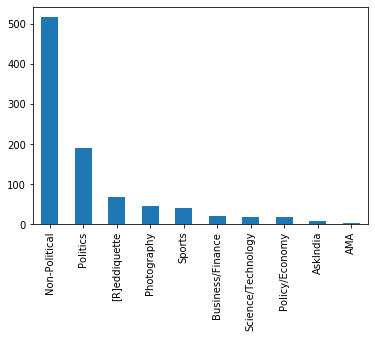

In [4]:
table.flair.value_counts().plot(kind='bar')

In [5]:
table.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 929 entries, 0 to 989
Data columns (total 6 columns):
Unnamed: 0    929 non-null int64
title         929 non-null object
body          69 non-null object
flair         929 non-null object
score         929 non-null int64
title+body    929 non-null object
dtypes: int64(2), object(4)
memory usage: 50.8+ KB


In [6]:
print(table.flair.value_counts())
print(table.flair.unique())

Non-Political         517
Politics              191
[R]eddiquette          67
Photography            46
Sports                 40
Business/Finance       21
Science/Technology     19
Policy/Economy         18
AskIndia                8
AMA                     2
Name: flair, dtype: int64
['Politics' 'Non-Political' '[R]eddiquette' 'Business/Finance'
 'Photography' 'Sports' 'Policy/Economy' 'Science/Technology' 'AskIndia'
 'AMA']


In [7]:
def print_plot(index):
    example = table[table.index == index][['title+body', 'flair']].values[0]
    return example[0], example[1]
#    if len(example) > 0:
#         print(example[0])
#         print('flair: ', example[1])
#         return example[0], example[1]
        

In [8]:
def values(index):
    return table['title+body'][index], table['flair'][index]

In [9]:
table_list = []
for i in table.index:
    title_body, flair = print_plot(i)
    flag = {
        "title+body": title_body,
        "flair": flair
    }
    table_list.append(flag)

In [10]:
table_list

[{'title+body': 'Unnao Accident ', 'flair': 'Politics'},
 {'title+body': "Reddit has been blocked in Kashmir, along with fifteen other social media sites, including Facebook, Twitter, Tumblr, WhatsApp, and Skype.Here's a copy of the order: https://twitter.com/internetfreedom/status/857213773320523776",
  'flair': 'Politics'},
 {'title+body': 'The vehicle for India!! ', 'flair': 'Non-Political'},
 {'title+body': "India's first LinkedIn based Matrimony! [NP] ",
  'flair': 'Non-Political'},
 {'title+body': 'stolen from r/wellthatsucks ', 'flair': 'Non-Political'},
 {'title+body': '"Andhadhun" has restored my faith in Indian Cinema. I don\'t watch Bollywood movies mainly because of the crapfests which they have been churning out every year. But this movie was amazeballs! ',
  'flair': 'Non-Political'},
 {'title+body': 'Every home today morning ', 'flair': 'Politics'},
 {'title+body': 'Andhra Pradesh should redesign this map/logo ',
  'flair': 'Non-Political'},
 {'title+body': 'Somewhere in

In [11]:
import pymongo

In [12]:
client = pymongo.MongoClient('mongodb://localhost:27017/')
instance = client['DataBase']
final = instance['site']

In [13]:
x = final.collection.insert(table_list)

/home/quarantine/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning: insert is deprecated. Use insert_one or insert_many instead.
  """Entry point for launching an IPython kernel.


In [14]:
x

[ObjectId('5d73edd6c23cd1a541431229'),
 ObjectId('5d73edd6c23cd1a54143122a'),
 ObjectId('5d73edd6c23cd1a54143122b'),
 ObjectId('5d73edd6c23cd1a54143122c'),
 ObjectId('5d73edd6c23cd1a54143122d'),
 ObjectId('5d73edd6c23cd1a54143122e'),
 ObjectId('5d73edd6c23cd1a54143122f'),
 ObjectId('5d73edd6c23cd1a541431230'),
 ObjectId('5d73edd6c23cd1a541431231'),
 ObjectId('5d73edd6c23cd1a541431232'),
 ObjectId('5d73edd6c23cd1a541431233'),
 ObjectId('5d73edd6c23cd1a541431234'),
 ObjectId('5d73edd6c23cd1a541431235'),
 ObjectId('5d73edd6c23cd1a541431236'),
 ObjectId('5d73edd6c23cd1a541431237'),
 ObjectId('5d73edd6c23cd1a541431238'),
 ObjectId('5d73edd6c23cd1a541431239'),
 ObjectId('5d73edd6c23cd1a54143123a'),
 ObjectId('5d73edd6c23cd1a54143123b'),
 ObjectId('5d73edd6c23cd1a54143123c'),
 ObjectId('5d73edd6c23cd1a54143123d'),
 ObjectId('5d73edd6c23cd1a54143123e'),
 ObjectId('5d73edd6c23cd1a54143123f'),
 ObjectId('5d73edd6c23cd1a541431240'),
 ObjectId('5d73edd6c23cd1a541431241'),
 ObjectId('5d73edd6c23cd1

In [15]:
print_plot(1)

("Reddit has been blocked in Kashmir, along with fifteen other social media sites, including Facebook, Twitter, Tumblr, WhatsApp, and Skype.Here's a copy of the order: https://twitter.com/internetfreedom/status/857213773320523776",
 'Politics')

In [16]:
import re
from nltk.corpus import stopwords
table = table.reset_index(drop=True)
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
STOPWORDS = set(stopwords.words('english'))

In [17]:
def clean_text(text):
    text = text.lower() # lowercase text
    text = REPLACE_BY_SPACE_RE.sub(' ', text) # replace REPLACE_BY_SPACE_RE symbols by space in text. substitute the matched string in REPLACE_BY_SPACE_RE with space.
    text = BAD_SYMBOLS_RE.sub('', text) # remove symbols which are in BAD_SYMBOLS_RE from text. substitute the matched string in BAD_SYMBOLS_RE with nothing. 
    text = text.replace('x', '') # text = re.sub(r'\W+', '', text)
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # remove stopwors from text
    return text

In [20]:
table['title'] = table['title'].str.replace('\d+', '')

In [21]:
max_words = 50000
max_sequence_len = 250
embedding = 100
filters = '!"#$%&()*+,-./:;<=>?@[\]^_`{|}~'

tokenizer = Tokenizer(num_words=max_words, filters=filters, lower=True)
tokenizer.fit_on_texts(table['title'].values)
word_index = tokenizer.word_index
print(word_index)
print('Found %s unique tokens.' % len(word_index))

{'the': 1, 'in': 2, 'a': 3, 'of': 4, 'to': 5, 'and': 6, 'this': 7, 'india': 8, 'i': 9, 'on': 10, 'is': 11, 'my': 12, 'for': 13, 'from': 14, 'you': 15, 'at': 16, 'indian': 17, 'it': 18, 'with': 19, 'by': 20, 'np': 21, 'was': 22, 'are': 23, 'his': 24, 'mumbai': 25, 'be': 26, 'first': 27, 'who': 28, 'x': 29, 'r': 30, 'me': 31, 'your': 32, 'when': 33, 'as': 34, 'up': 35, 'not': 36, 'have': 37, 'an': 38, 'that': 39, 'people': 40, 'one': 41, 'like': 42, 'no': 43, 'after': 44, 'just': 45, 'has': 46, 'delhi': 47, 'our': 48, 'day': 49, 'he': 50, 'made': 51, 'how': 52, 'today': 53, 'kerala': 54, 'oc': 55, 'all': 56, 'two': 57, 'world': 58, 'found': 59, "don't": 60, 'year': 61, 'but': 62, 'them': 63, 'her': 64, 'post': 65, 'hyderabad': 66, 'we': 67, 'new': 68, 'time': 69, 'should': 70, 'about': 71, 'old': 72, 'here': 73, 'so': 74, 'their': 75, 'these': 76, 'modi': 77, 'what': 78, 'last': 79, 'if': 80, 'been': 81, 'morning': 82, 'police': 83, 'right': 84, 'had': 85, 'got': 86, 'get': 87, 'can': 88

In [22]:
from keras.preprocessing.sequence import pad_sequences
X = tokenizer.texts_to_sequences(table['title'].values)
X = pad_sequences(X, maxlen=max_sequence_len)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (929, 250)


In [23]:
Y = pd.get_dummies(table['flair']).values
print('Shape of label tensor:', Y.shape)
table.flair.unique()

Shape of label tensor: (929, 10)


array(['Politics', 'Non-Political', '[R]eddiquette', 'Business/Finance',
       'Photography', 'Sports', 'Policy/Economy', 'Science/Technology',
       'AskIndia', 'AMA'], dtype=object)

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.10, random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(836, 250) (836, 10)
(93, 250) (93, 10)


In [25]:
model = Sequential()
model.add(Embedding(max_words, embedding, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(64, activation='relu'))
#model.add(LSTM(64, dropout=0.15, recurrent_dropout=0.15))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())





Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 250, 100)          5000000   
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, 250, 100)          0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 128)               117248    
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_2 (Dense)              (None, 10)                650       
Total params: 5,126,154
Trainable params: 5,126,154
Non-trainable params: 0
_______________________________________________________

In [29]:
from keras.callbacks import EarlyStopping
epochs = 50
batch_size = 64

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.1,callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)])

Train on 752 samples, validate on 84 samples
Epoch 1/50
752/752 [==============================] - 5s 6ms/step - loss: 0.7374 - acc: 0.7580 - val_loss: 1.7075 - val_acc: 0.5476
Epoch 2/50
752/752 [==============================] - 5s 6ms/step - loss: 0.6418 - acc: 0.7992 - val_loss: 1.9188 - val_acc: 0.5238
Epoch 3/50
752/752 [==============================] - 5s 6ms/step - loss: 0.5379 - acc: 0.8391 - val_loss: 2.1077 - val_acc: 0.4762
Epoch 4/50
752/752 [==============================] - 5s 6ms/step - loss: 0.4457 - acc: 0.8684 - val_loss: 2.3616 - val_acc: 0.4405


In [30]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

93/93 [==============================] - 0s 2ms/step
Test set
  Loss: 2.176
  Accuracy: 0.516


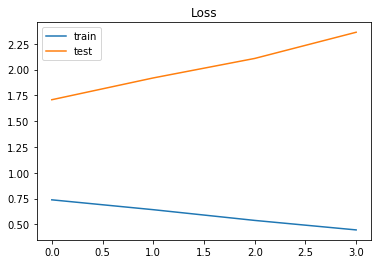

In [31]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

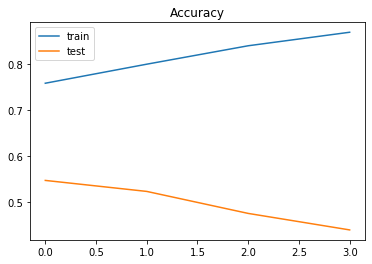

In [32]:
plt.title('Accuracy')
plt.plot(history.history['acc'], label='train')
plt.plot(history.history['val_acc'], label='test')
plt.legend()
plt.show();

In [33]:
post_text = input("enter post text: ")
seq = tokenizer.texts_to_sequences(post_text)
padded = pad_sequences(seq, maxlen=max_sequence_len)
pred = model.predict(padded)
labels = ['Politics','[R]eddiquette','Non-Political','AskIndia','Policy/Economy','Business/Finance','Science/Technology','Sports','Photography','AMA']
print(pred, labels[np.argmax(pred)])

enter post text: p chindambram arrested because of fraud and felony
[[1.81570795e-04 6.83559047e-04 3.37355188e-03 4.92050126e-02
  4.46803449e-03 2.95177288e-03 9.02967334e-01 1.53835118e-03
  3.31321592e-03 3.13176624e-02]
 [4.98758804e-04 1.91337150e-03 1.07681882e-02 1.30173385e-01
  1.25544528e-02 8.27306416e-03 6.60069525e-01 4.40052617e-03
  1.47207016e-02 1.56628013e-01]
 [7.43480457e-04 1.29855867e-03 2.01728456e-02 1.02378381e-02
  3.27263698e-02 1.93196256e-02 7.06914961e-01 9.43037402e-03
  1.57276969e-02 1.83428168e-01]
 [4.98758804e-04 1.91337150e-03 1.07681882e-02 1.30173385e-01
  1.25544528e-02 8.27306416e-03 6.60069525e-01 4.40052617e-03
  1.47207016e-02 1.56628013e-01]
 [4.44323523e-04 2.34141503e-03 9.77552123e-03 3.20209622e-01
  1.07872272e-02 7.07101403e-03 4.41732138e-01 3.93224880e-03
  1.89956408e-02 1.84710816e-01]
 [4.98758804e-04 1.91337150e-03 1.07681882e-02 1.30173385e-01
  1.25544528e-02 8.27306416e-03 6.60069525e-01 4.40052617e-03
  1.47207016e-02 1.5662